In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

print("\nGPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install -q tensorflow

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from google.colab import drive

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
PROJECT_DIR="/content/drive/MyDrive/computervisionproject"

DATASET=os.path.join(
    PROJECT_DIR,
    "dataset",
    "processed_dataset"
)

MODEL_DIR=os.path.join(
    PROJECT_DIR,
    "models"
)

os.makedirs(MODEL_DIR,exist_ok=True)

TRAIN=os.path.join(DATASET,"train")
VAL=os.path.join(DATASET,"val")
TEST=os.path.join(DATASET,"test")

In [6]:
IMG_SIZE=(224,224)

BATCH_SIZE=32

AUTOTUNE=tf.data.AUTOTUNE

NUM_CLASSES=3

SEED=42

In [7]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    TRAIN,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds=tf.keras.utils.image_dataset_from_directory(
    VAL,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds=tf.keras.utils.image_dataset_from_directory(
    TEST,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 12121 files belonging to 3 classes.
Found 1514 files belonging to 3 classes.
Found 1518 files belonging to 3 classes.


In [8]:
CLASS_NAMES=train_ds.class_names

print(CLASS_NAMES)

['COVID', 'Normal', 'Viral Pneumonia']


In [9]:
train_ds=train_ds.prefetch(AUTOTUNE)

val_ds=val_ds.prefetch(AUTOTUNE)

test_ds=test_ds.prefetch(AUTOTUNE)

In [10]:
data_augmentation=models.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.05),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10)

])

In [11]:
base_model=EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(224,224,3)

)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
base_model.trainable=False

print("Trainable:",base_model.trainable)

Trainable: False


In [13]:
inputs=layers.Input(shape=(224,224,3))

x=data_augmentation(inputs)

x=preprocess_input(x)

x=base_model(x,training=False)

x=layers.GlobalAveragePooling2D()(x)

x=layers.Dropout(0.3)(x)

outputs=layers.Dense(

    NUM_CLASSES,

    activation="softmax"

)(x)

model=models.Model(inputs,outputs)

In [14]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=1e-3

    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [16]:
checkpoint=ModelCheckpoint(

    filepath=os.path.join(

        MODEL_DIR,

        "baseline.keras"

    ),

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

early=EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

reduce=ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    verbose=1

)

In [17]:
history=model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=15,

    callbacks=[

        checkpoint,

        early,

        reduce

    ]

)

Epoch 1/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7873 - loss: 0.5049
Epoch 1: val_accuracy improved from None to 0.84610, saving model to /content/drive/MyDrive/computervisionproject/models/baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/computervisionproject/models/baseline.keras
379/379 ━━━━━━━━━━━━━━━━━━━━ 1818s 5s/step - accuracy: 0.8393 - loss: 0.4000 - val_accuracy: 0.8461 - val_loss: 0.3703 - learning_rate: 0.0010
Epoch 2/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8864 - loss: 0.3000
Epoch 2: val_accuracy improved from 0.84610 to 0.89102, saving model to /content/drive/MyDrive/computervisionproject/models/baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/computervisionproject/models/baseline.keras
379/379 ━━━━━━━━━━━━━━━━━━━━ 62s 163ms/step - accuracy: 0.8897 - loss: 0.2925 - val_accuracy: 0.8910 - val_loss: 0.2814 - learning_rate: 0.0010
Epoch 3/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accur

In [18]:
model.save(

    os.path.join(

        MODEL_DIR,

        "baseline_final.keras"

    )

)

print("Baseline Model Saved.")

Baseline Model Saved.


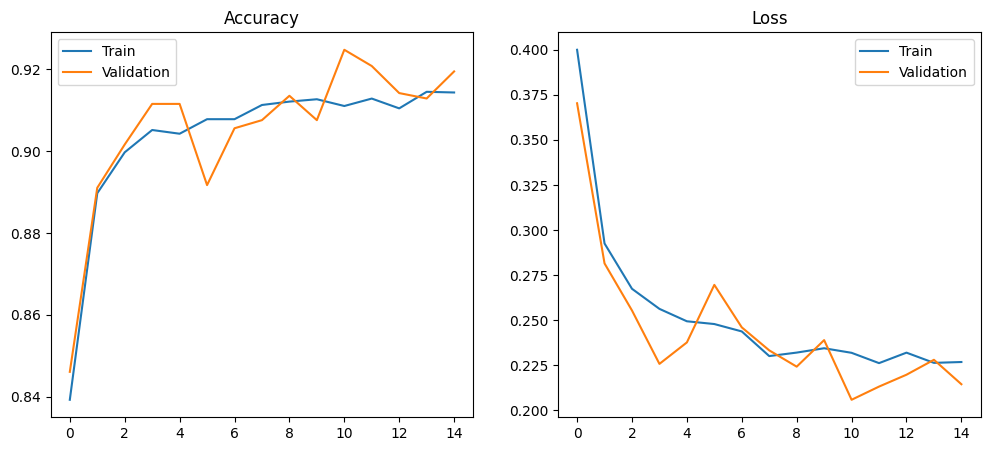

In [19]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.title("Accuracy")

plt.subplot(1,2,2)

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.title("Loss")

plt.show()

In [20]:
loss,accuracy=model.evaluate(test_ds)

print()

print("Test Accuracy:",accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 265s 6s/step - accuracy: 0.9157 - loss: 0.2183

Test Accuracy: 0.9156785011291504
